# How many attention heads does a task need?

**Question.** Can a model find, during one training run, the smallest set of attention heads
that does a task?

**Claim, in three parts.**

1. On a task where the answer is known, simple algebra says exactly how many heads are
   needed, and training agrees.
2. A rule that only compares heads with each other cannot find that number.
3. A rule that keeps a head only for **what no other head can cover** finds it, removes
   duplicates, and never loses the task while removing heads. The idea comes from
   *collateral circulation*: losing a blood vessel is harmless if neighbouring vessels cover
   its area. Each ingredient is tested by taking it away.

Every number below is computed from the saved training runs.

In [1]:
import glob, pickle, sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.insert(0, "../src")
from hemo.config import Cfg

BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#9c9a93"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titlelocation": "left", "axes.titleweight": "bold", "font.size": 9,
                     "legend.frameon": False})

RUNS = []
for path in glob.glob("../results/*.pkl") + glob.glob("../results/proposal/*.pkl"):
    r = pickle.load(open(path, "rb"))
    if "hist" in r:
        RUNS.append(r)

DEFAULT = Cfg()
FIXED = dict(task="multi_relation", steps=4000, d_k=32, demand="outnorm_ema", kappa_end=1.5,
             target_frac=0.02, leak=0.0, delay=0, pool_beta=0.0, stall_gate=0.0,
             autoreg_gain=0.003, price_frac=0.01, probe_every=25, taper=0,
             budget_hold_frac=0.25, prune_stop=1, conserve=1, local_value="refit", plant_copies=0)


def get(run, key):
    return run["cfg"].get(key, getattr(DEFAULT, key))


def runs(**want):                   # every setting not asked for is held at its standard value
    want = {**FIXED, **want}
    return [r for r in RUNS if all(get(r, k) == v for k, v in want.items())]


def heads_kept(run):                # median number of heads on, over the last part of training
    on = (run["hist"]["ledger"] > 0).sum(1)
    return float(np.median(on[int(0.75 * len(on)):]))


def worst_after_solved(run):        # worst loss after first reaching the solved bar, in units of the bar
    h, bar = run["hist"], 0.02 * run["trivial"]
    start = get(run, "budget_hold_frac") * get(run, "steps")
    losses = [l for s, l in zip(h["val_step"], h["val_loss"]) if s >= start]
    first = next(i for i, l in enumerate(losses) if l < bar)
    return max(losses[first:]) / bar


RULE = dict(supply="local", price_frac=0.03, taper=100, budget_hold_frac=0.1)
print(len(RUNS), "training runs loaded")

533 training runs loaded


## 1. The task needs exactly $R$ heads

**The task.** A memory has 16 slots, each holding a random vector. A query carries a
position $p$ and must return the contents of the slots $1, 5, 9, 13$ places ahead
(wrapping around). So it must return $R = 4$ unknown vectors
$c_1, c_2, c_3, c_4$.

**What one head can give.** A head averages the slots it looks at, so it returns one
**blend**: $u = a_1 c_1 + a_2 c_2 + a_3 c_3 + a_4 c_4$. That is one equation in the
unknowns. With $k$ heads,

$$U = A\,C, \qquad A = \text{a } k \times R \text{ matrix of blend weights.}$$

To recover all $R$ unknowns, the blends must be $R$ *different* equations:
$\operatorname{rank}(A) = R$, so **$k \ge R$**. By hand with 2 unknowns: $x + y = 10$ alone
cannot be solved; add $x - y = 2$ and $x = 6, y = 4$; but adding $2x + 2y = 20$ changes
nothing, because it is the same equation again.

**How much loss is left with fewer heads.** Each missing equation leaves one of the $R$
vectors unknown, so

$$L(k) = \Big(1 - \frac{\text{number of different heads}}{R}\Big)\, L_{\text{trivial}},$$

where $L_{\text{trivial}}$ is the loss of a model that learned nothing. At $R = 4$: 0.75,
0.50, 0.25, 0 of $L_{\text{trivial}}$.

**Test.** Train a 4-head model. Then let the output layer use only some heads, or a head
together with an exact **copy** of it, and refit.

heads used             different  measured  predicted
h1 + h2 + h3 + h4              4     0.000      0.000
h1 + h2 + h3                   3     0.254      0.252
h1 + h3 + h4                   3     0.254      0.252
h1 + h2                        2     0.507      0.504
h3 + h4                        2     0.507      0.504
h2                             1     0.758      0.756
h4                             1     0.759      0.756
h1 + h1 + h3 + h4              3     0.254      0.252
h1 + h2 + h2 + h2              2     0.507      0.504


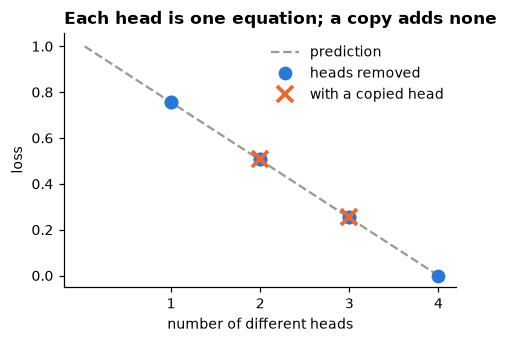

In [2]:
E1 = pickle.load(open("../results/proposal/equations.pkl", "rb"))
triv = E1["trivial"]
print(f"{'heads used':<22}{'different':>10}{'measured':>10}{'predicted':>11}")
for row in E1["rows"]:
    print(f"{row['name']:<22}{row['different']:>10}{row['loss']:>10.3f}{row['predicted']:>11.3f}")

fig, ax = plt.subplots(figsize=(4.6, 3))
d = np.array([0, 4])
ax.plot(4 - d, (1 - (4 - d) / 4) * triv, ls="--", color=GREY, label="prediction")
plain = [r for r in E1["rows"] if len(set(r["heads"])) == len(r["heads"])]
copies = [r for r in E1["rows"] if len(set(r["heads"])) < len(r["heads"])]
ax.plot([r["different"] for r in plain], [r["loss"] for r in plain], "o", color=BLUE, ms=8, label="heads removed")
ax.plot([r["different"] for r in copies], [r["loss"] for r in copies], "x", color=ORANGE, ms=11, mew=2.5,
        label="with a copied head")
ax.set(xlabel="number of different heads", ylabel="loss", xticks=[1, 2, 3, 4])
ax.legend()
ax.set_title("Each head is one equation; a copy adds none")
plt.show()

The measured losses sit on the predicted line, and **a copied head counts as nothing**:
4 heads with one copy behave exactly like 3 heads.

## 2. Comparing heads with each other cannot count them

The obvious rule keeps every head whose activity is more than $\kappa$ standard deviations
above average:

$$\text{keep } h \iff z_h = \frac{d_h - \text{mean}(d)}{\text{std}(d)} > \kappa .$$

**By hand.** Activities $d = (1,1,1,1,1,1,5,5)$: mean 2, std 1.85, so with $\kappa = 1$ the
last two heads are kept. Multiply every activity by 10 and add 100: mean 120, std 18.5,
and the **same two heads** are kept. The $z$-scores never change, so the count depends only
on the *shape* of the activities, never on what the task needs. Grading on a curve always
hands out about the same number of top grades, however hard the exam.

Rules that instead check the model's **loss** can count. Below, heads kept against heads
needed, for this rule, the standard pruning method (remove the least important head until
the loss gets worse), and the collateral rule of Section 3.

rule                          k*=2     4     8   worst loss after solved (x bar, median)
compare heads (threshold)      2.7   4.0   4.0   34.9
standard pruning               2.0   4.0   8.7   26.0
collateral rule                2.0   4.0   8.0   0.6


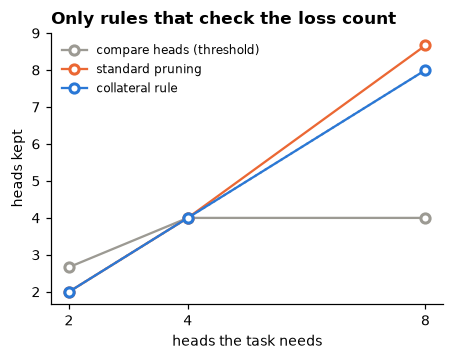

In [3]:
ARMS = {"compare heads (threshold)": (dict(supply="threshold"), GREY),
        "standard pruning": (dict(supply="prune"), ORANGE),
        "collateral rule": ({**RULE, "conserve": 0}, BLUE)}
fig, ax = plt.subplots(figsize=(4.6, 3.2))
ax.plot([2, 8], [2, 8], ":", color=GREY)
print(f"{'rule':<28}{'k*=2':>6}{'4':>6}{'8':>6}   worst loss after solved (x bar, median)")
for name, (kw, color) in ARMS.items():
    B = {k: np.mean([heads_kept(r) for r in runs(**kw, n_rel=k)]) for k in (2, 4, 8)}
    w = np.median([worst_after_solved(r) for k in (2, 4, 8) for r in runs(**kw, n_rel=k)])
    print(f"{name:<28}" + "".join(f"{B[k]:>6.1f}" for k in B) + f"   {w:.1f}")
    ax.plot(list(B), list(B.values()), "o-", color=color, mfc="white", mew=2, label=name)
ax.set(xlabel="heads the task needs", ylabel="heads kept", xticks=[2, 4, 8])
ax.legend(fontsize=8)
ax.set_title("Only rules that check the loss count")
plt.show()

The threshold rule never keeps more than about 4 heads, so it falls further short the more
heads the task needs. Standard pruning counts,
but its loss jumps far above the solved bar while it removes heads (last column). The
collateral rule counts **and** never falls back above the bar.

## 3. The collateral rule: a head is worth what nobody else can cover

Every 25 training steps, give each head a value: the rise in error when it is removed and
the **other heads re-fit** their output weights to cover for it.

$$v_h = E(\text{all heads except } h,\ \text{re-fitted}) \;-\; E(\text{all heads}).$$

Close the cheapest head if $v_h$ is below a price. The closing head fades out over 100
steps.

**By hand, why this is different from ordinary importance.** Heads A and B both output the
same signal $z$; head C outputs $w$; the target is $z + w$. The best fit splits the work,
$\hat t = \tfrac12 A + \tfrac12 B + C$.

- *Ordinary importance* (remove A, no re-fit): the prediction loses $\tfrac12 z$, so the
  error rises by $\operatorname{var}(z)/4$. A looks important, and so does B.
- *Collateral value* (remove A, re-fit): B takes A's weight and **nothing is lost**, so
  $v_A = 0$. The same for B. So one copy is closed; then the other is no longer a copy and
  stays.

In [4]:
rng = np.random.default_rng(0)
z, w = rng.normal(size=100_000), rng.normal(size=100_000)
A, B, C, t = z, z, w, z + w
err = lambda X, coef: np.mean((t - X @ coef) ** 2)
fit = lambda X: np.linalg.lstsq(X, t, rcond=None)[0]
full = np.stack([A, B, C], 1)
coef = fit(full)
print("fitted weights (A, B, C):", coef.round(2))
print(f"ordinary importance of A (no re-fit): {err(full[:, 1:], coef[1:]) - err(full, coef):.3f}"
      f"   (by hand: var(z)/4 = {z.var() / 4:.3f})")
print(f"collateral value of A (re-fit):       {err(full[:, 1:], fit(full[:, 1:])) - err(full, coef):.3f}")

fitted weights (A, B, C): [0.5 0.5 1. ]


ordinary importance of A (no re-fit): 0.250   (by hand: var(z)/4 = 0.250)
collateral value of A (re-fit):       0.000


**Test 1: planted copies.** Start training with every head paired with an exact copy.

In [5]:
print(f"{'value used':<22}{'heads kept':>11}{'pairs of copies both kept':>28}")
for value, name in [("refit", "collateral"), ("ablate", "ordinary importance")]:
    for r in runs(**RULE, n_rel=4, plant_copies=1, local_value=value):
        on = r["hist"]["ledger"][-1] > 0
        print(f"{name:<22}{int(on.sum()):>11}{sum(bool(on[h] and on[h + 16]) for h in range(16)):>28}")

value used             heads kept   pairs of copies both kept


collateral                      4                           0
collateral                      4                           0
collateral                      4                           0
ordinary importance            12                           5
ordinary importance            12                           5
ordinary importance            15                           7


The task needs 4 heads. The collateral rule keeps exactly 4, never two copies of the same
head. Ordinary importance keeps 12 to 15, including several pairs of copies.

**Test 2: take each ingredient away** (3 seeds at each of $k^\star = 2, 4, 8$). A good
ingredient, when removed, should make the count or the stability worse.

                                     extra heads kept   worst loss after solved
collateral rule (as first built)                  0.7                   0.6 x bar   (9 runs)
  without the fixed total                         0.0                   0.6 x bar   (9 runs)
  random head instead of cheapest                 0.1                   6.5 x bar   (9 runs)
  ordinary importance instead                     4.0                   0.5 x bar   (9 runs)
  no fade                                         0.2                  12.3 x bar   (6 runs)


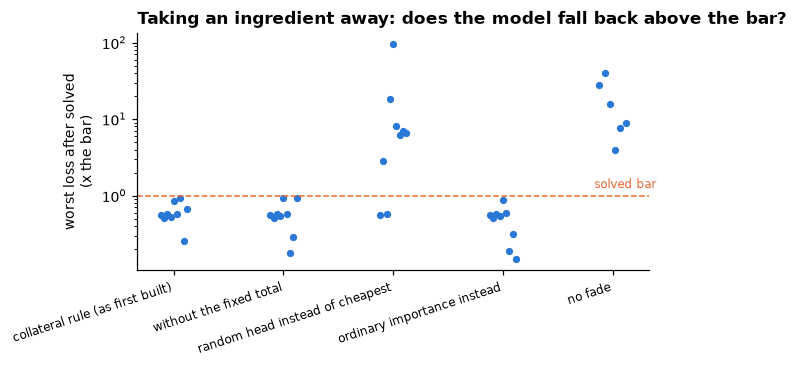

In [6]:
CONTROLS = {"collateral rule (as first built)": RULE,
            "  without the fixed total": {**RULE, "conserve": 0},
            "  random head instead of cheapest": {**RULE, "local_value": "random"},
            "  ordinary importance instead": {**RULE, "local_value": "ablate"},
            "  no fade": {**RULE, "taper": 0}}
print(f"{'':<36}{'extra heads kept':>17}{'worst loss after solved':>26}")
spread = {}
for name, kw in CONTROLS.items():
    rs = [r for k in (2, 4, 8) for r in runs(**kw, n_rel=k)]
    extra = np.mean([heads_kept(r) - get(r, "n_rel") for r in rs])
    spread[name] = [worst_after_solved(r) for r in rs]
    print(f"{name:<36}{extra:>17.1f}{np.median(spread[name]):>22.1f} x bar   ({len(rs)} runs)")

fig, ax = plt.subplots(figsize=(6, 2.8))
for i, (name, w) in enumerate(spread.items()):
    ax.scatter(np.full(len(w), i) + np.linspace(-0.12, 0.12, len(w)), w, s=14, color=BLUE)
ax.axhline(1, color=ORANGE, ls="--", lw=1)
ax.text(4.4, 1.25, "solved bar", color=ORANGE, fontsize=8, ha="right")
ax.set(yscale="log", ylabel="worst loss after solved\n(x the bar)")
ax.set_xticks(range(len(spread)), [n.strip() for n in spread], rotation=18, ha="right", fontsize=8)
ax.set_title("Taking an ingredient away: does the model fall back above the bar?")
plt.show()

| Ingredient (from the biology) | Removed → | Earns its place? |
|---|---|---|
| collateral value (collateral circulation) | wrong heads closed, loss jumps; or redundant heads kept | **yes** |
| slow fading (vessels constrict gradually) | loss jumps above the bar | **yes** |
| fixed total supply (autoregulation) | count becomes *exact* | **no**, so the final rule drops it |

The final rule is the collateral rule **without** the fixed total: 0.0 extra heads on
average, so exactly 2, 4 and 8 heads (Section 2).

## 4. Limits, and the next question

**Limits.**

- One synthetic task and one layer. On a second task the rule worked at one setting and
  failed at another.
- Three seeds per setting.
- Compute: one run is cheaper than trying model sizes one by one only when the circuit is
  large. Compute figures are operation counts, not timings.

**Next question: when does a circuit keep backup heads?** Language models keep backup
heads that take over when one is removed (the Hydra effect), and why is open. The collateral
rule gives a testable answer. If heads fail at random with probability $p$ during training,
a backup is worth about $p \times \frac{1}{R} L_{\text{trivial}}$ (it saves one of $R$ jobs
whenever its original fails), so it should be kept only when that beats the price:

$$\text{backups appear when } p > \text{price} \times R \qquad (\text{here } 0.03 \times 4 = 0.12).$$

This mirrors blood vessels, which keep extra connecting routes where blockages keep happening. It is a
prediction, not yet a result.